In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", decimal=",", encoding="utf-8-sig")
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", decimal=",", encoding="utf-8-sig")

In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

In [5]:
path = "Tabela 1.1.1.xls"
bruto = pd.read_excel(path, engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

In [6]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
estados_1_1_1 = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)].copy()

In [7]:
cruzado = comp.merge(estados_1_1_1, left_on="Estado", right_on="uf_regiao", how="inner")
cruzado = cruzado.drop(columns="uf_regiao")

In [8]:
ordem = comp.sort_values("Desocupados - mulheres (2026 T1)")["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["Desocupados - mulheres (2012 T1)", "Desocupados - mulheres (2026 T1)"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({
    "Desocupados - mulheres (2012 T1)": "2012 T1",
    "Desocupados - mulheres (2026 T1)": "2026 T1",
})

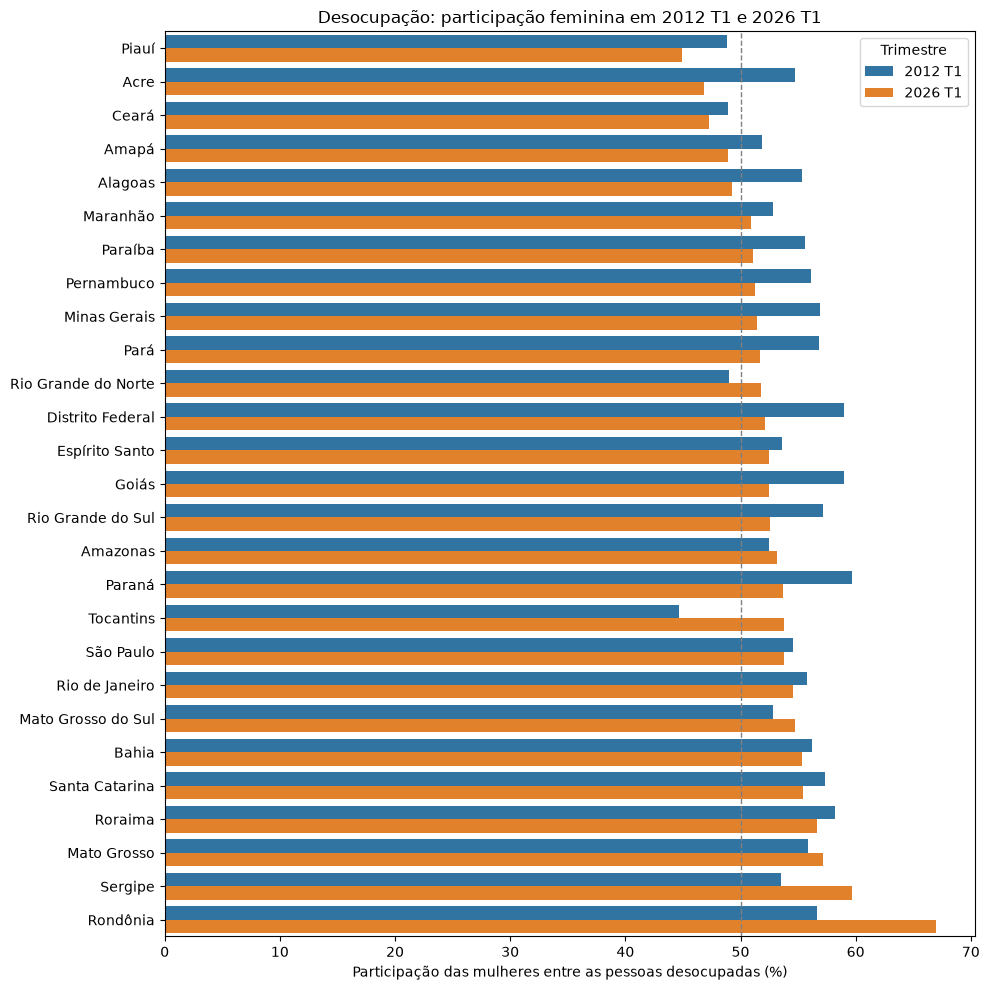

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
plt.show()